Loaded arrays with shapes:
T_all_n: (300, 2, 4)
H_all_n: (300, 2, 4)
taus: (4,)
beads: (2,)
Heat capacity computations saved successfully to data_Cv_T_n300_w1_0.csv and data_Cv_H_n300_w1_0.csv!


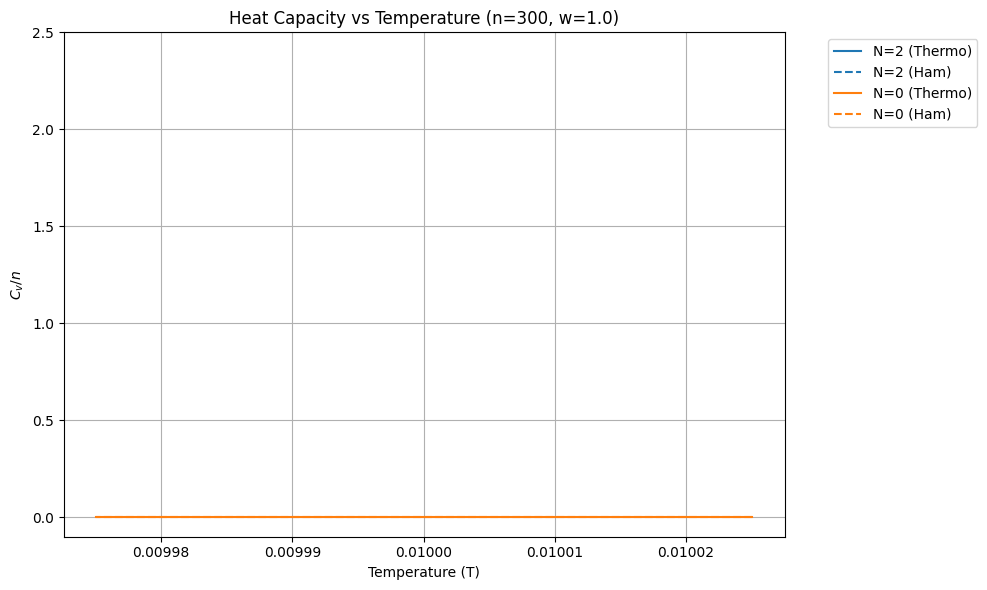

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_heat_capacity(tau_vals, E_vals):
    # Vectorized computation for better performance
    dE = np.diff(E_vals, axis=-1)
    dtau = np.diff(tau_vals)
    tau_mid = (tau_vals[1:] + tau_vals[:-1]) / 2.0
    C_v = -(tau_mid**2) * (dE / dtau)
    return C_v
n_val = 300
w_val = 1.0
save_filename = f"Saved_runs_and_plots/plot_data_n{n_val}_w{str(w_val).replace('.', '_')}"

try:
    arr_T = np.load(f"{save_filename}_T_all_n.npy")
    arr_H = np.load(f"{save_filename}_H_all_n.npy")
    taus = np.load(f"{save_filename}_taus.npy")
    beads = np.load(f"{save_filename}_beads.npy")
    
    print(f"Loaded arrays with shapes:")
    print(f"T_all_n: {arr_T.shape}")
    print(f"H_all_n: {arr_H.shape}")
    print(f"taus: {taus.shape}")
    print(f"beads: {beads.shape}")
    
    target_n = 300 # <--- Change this to the specific n you want to plot
    n_idx = target_n - 1
    
    # Calculate midpoints for tau and compute Temperature
    n_tau = len(taus)
    midpoint_taus = (taus[1:] + taus[:-1]) / 2.0
    Temp = 1.0 / midpoint_taus

    results_df_T = pd.DataFrame({"Temperature": Temp})
    results_df_H = pd.DataFrame({"Temperature": Temp})

    plt.figure(figsize=(10, 6))
    
    # Extract Exact N=256 heat capacities from the loaded arrays
    # exact_bead_idx = np.where(beads == 256)[0][0]
    # exact_energy_H = arr_H[n_idx, exact_bead_idx, :]
    # Cv_exact_H = compute_heat_capacity(taus, exact_energy_H) / target_n
    # results_df_H["Exact_N_256"] = Cv_exact_H
    # line, = plt.plot(Temp, Cv_exact_H, linestyle="--", color="black", linewidth=2, label="Exact N=256 (Ham)")
    
    
    for bead_idx, bead in enumerate(beads):
        if bead == 256:
            continue
        
        energy_T = arr_T[n_idx, bead_idx, :]
        energy_H = arr_H[n_idx, bead_idx, :]
        
        Cv_T = compute_heat_capacity(taus, energy_T) / target_n
        Cv_H = compute_heat_capacity(taus, energy_H) / target_n
        
        results_df_T[f"N_{bead}"] = Cv_T
        results_df_H[f"N_{bead}"] = Cv_H
        
        line, = plt.plot(Temp, Cv_T, label=f"N={bead} (Thermo)")
        plt.plot(Temp, Cv_H, linestyle="--", color=line.get_color(), label=f"N={bead} (Ham)")
        
    output_filename_T = f"data_Cv_T_n{target_n}_w{str(w_val).replace('.', '_')}.csv"
    output_filename_H = f"data_Cv_H_n{target_n}_w{str(w_val).replace('.', '_')}.csv"
    
    results_df_T.to_csv(output_filename_T, index=False)
    results_df_H.to_csv(output_filename_H, index=False)
    
    print(f"Heat capacity computations saved successfully to {output_filename_T} and {output_filename_H}!")
    
    plt.xlabel("Temperature (T)")
    plt.ylabel(r"$C_v / n$")
    #plt.xlim(0,10)
    plt.ylim(-0.1,2.5)
    plt.title(f"Heat Capacity vs Temperature (n={target_n}, w={w_val})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the files starting with '{save_filename}'.")


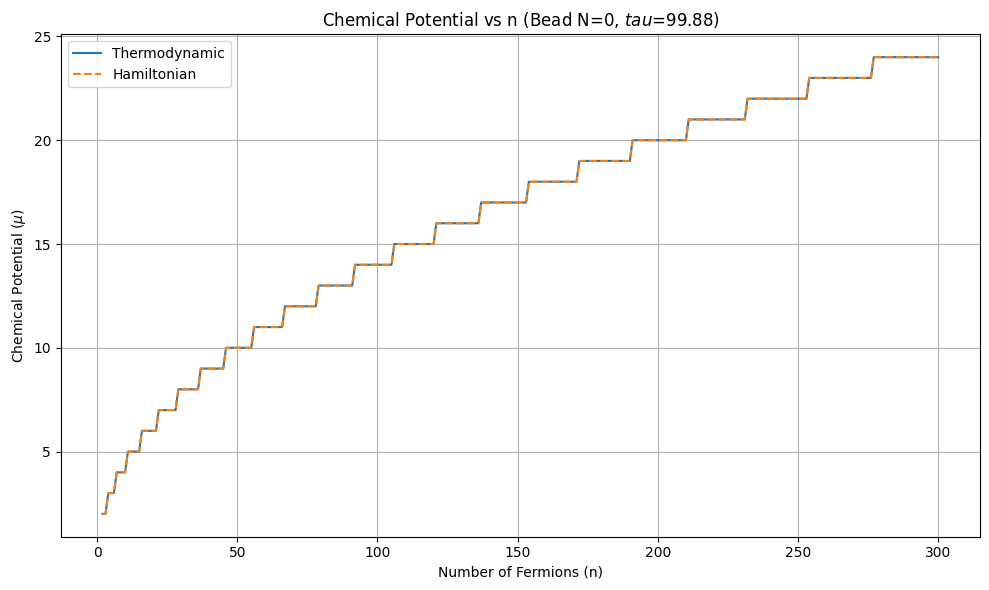

In [6]:
# --- Chemical Potential vs n Plot ---
# Chemical potential is the change in energy when adding one fermion: mu(n) = E(n) - E(n-1)

# You can change these to select which slice you want to plot
target_bead = 0
target_tau_idx = 1  # Index for tau array

# Compute Chemical Potential by differentiating along the 'n' axis (axis 0)
mu_T = np.diff(arr_T, axis=0)
mu_H = np.diff(arr_H, axis=0)

# Since we took a difference, the array size is reduced by 1. 
# Index 0 of mu corresponds to the step from n=1 to n=2, so our n_vals start at 2.
n_vals = np.arange(2, n_val + 1)

bead_idx = np.where(beads == target_bead)[0][0]

mu_T_slice = mu_T[:, bead_idx, target_tau_idx]
mu_H_slice = mu_H[:, bead_idx, target_tau_idx]

plt.figure(figsize=(10, 6))
plt.plot(n_vals, mu_T_slice, label="Thermodynamic", linestyle="-")
plt.plot(n_vals, mu_H_slice, label="Hamiltonian", linestyle="--")

plt.xlabel("Number of Fermions (n)")
plt.ylabel(r"Chemical Potential ($\mu$)")
plt.title(f"Chemical Potential vs n (Bead N={target_bead}, $tau$={taus[target_tau_idx]:.2f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Computing Thomas-Fermi limit vs n... (this might take a few seconds)


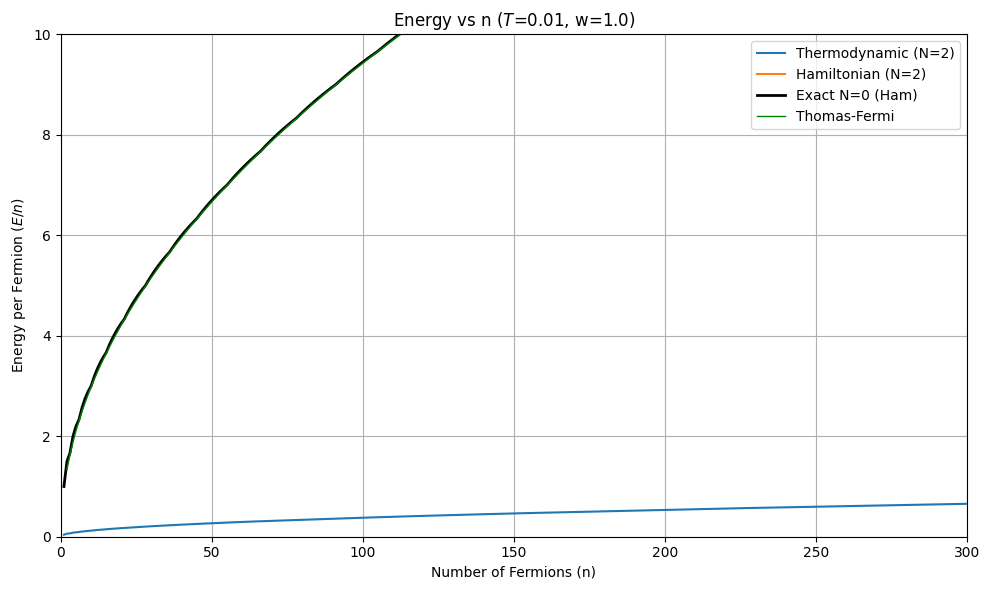

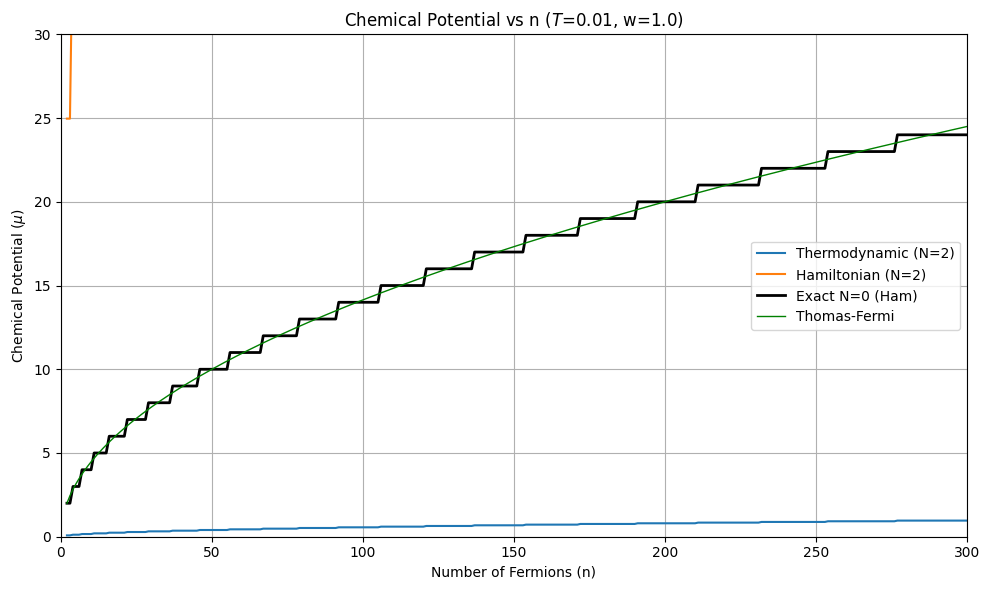

In [8]:
# --- Comparison with Thomas-Fermi (Semiclassical) Limit vs n ---
from scipy.integrate import quad
from scipy.optimize import root_scalar
import time
import os
import numpy as np
import matplotlib.pyplot as plt

print("Computing Thomas-Fermi limit vs n... (this might take a few seconds)")

target_bead = 2
target_tau_idx = 0  # Choose a specific tau index for the plots
ntop = 300

bead_idx = np.where(beads == target_bead)[0][0]
tau = taus[target_tau_idx]
T_fixed = 1.0 / tau

# 1. Extract Energy per fermion vs n
n_vals_all = np.arange(1, n_val + 1)
E_T_n = arr_T[:, bead_idx, target_tau_idx] / n_vals_all
E_H_n = arr_H[:, bead_idx, target_tau_idx] / n_vals_all

target_bead_high = 0
has_high_beads = False
if 0 in beads:
    exact_bead_idx = np.where(beads == 0)[0][0]
    n_val_high = arr_H.shape[0]
    E_H_n_high = arr_H[:, exact_bead_idx, target_tau_idx] / np.arange(1, n_val_high + 1)
    has_high_beads = True
else:
    print("Could not find high bead data in loaded arrays.")

# 2. Compute Heat Capacity vs n
# We differentiate along the tau axis (-1) for all n at once
dE_T_tau = np.diff(arr_T[:, bead_idx, :], axis=-1)
dE_H_tau = np.diff(arr_H[:, bead_idx, :], axis=-1)
tau_mid = (taus[1:] + taus[:-1]) / 2.0

Cv_T_all = -(tau_mid**2) * (dE_T_tau / np.diff(taus))
Cv_H_all = -(tau_mid**2) * (dE_H_tau / np.diff(taus))

if has_high_beads:
    dE_H_tau_high = np.diff(arr_H[:, exact_bead_idx, :], axis=-1)
    Cv_H_all_high = -(tau_mid**2) * (dE_H_tau_high / np.diff(taus))

# Note: target_tau_idx might need adjusting because tau_mid is 1 element shorter.
Cv_T_n = Cv_T_all[:, target_tau_idx] / n_vals_all
Cv_H_n = Cv_H_all[:, target_tau_idx] / n_vals_all
if has_high_beads:
    Cv_H_n_high = Cv_H_all_high[:, target_tau_idx] / np.arange(1, n_val_high + 1)

# 3. Compute Chemical Potential vs n
mu_T_all = np.diff(arr_T[:, bead_idx, target_tau_idx])
mu_H_all = np.diff(arr_H[:, bead_idx, target_tau_idx])
n_vals_mu = np.arange(2, n_val + 1)
if has_high_beads:
    mu_H_all_high = np.diff(arr_H[:, exact_bead_idx, target_tau_idx])

# --- Thomas-Fermi Calculations vs n ---
# Ensure we use the correct frequency for the TF integrals
# w_val is already set in the first cell, so we use it directly.
def N_int(mu, T):
    def integrand(e):
        x = (e - mu)/T
        if x > 100: return 0.0
        return (e / w_val**2) / (np.exp(x) + 1.0)
    return quad(integrand, 0, max(0, mu) + 40*T)[0]

def E_int(mu, T):
    def integrand(e):
        x = (e - mu)/T
        if x > 100: return 0.0
        return (e**2 / w_val**2) / (np.exp(x) + 1.0)
    return quad(integrand, 0, max(0, mu) + 40*T)[0]

# Calculate TF limit for integer n values to match the exact data
n_vals_TF = np.arange(2, ntop + 1)
E_TF_n = np.zeros(len(n_vals_TF))
Cv_TF_n = np.zeros(len(n_vals_TF))
mu_TF = np.zeros(len(n_vals_TF))

# To compute TF Cv, we need E_TF at T and T+dT
dT = 0.01
T2 = T_fixed + dT

for i, n_target in enumerate(n_vals_TF):
    mu0 = np.sqrt(2 * n_target) * w_val
    
    # At T_fixed
    def obj1(mu): return N_int(mu, T_fixed) - n_target
    res1 = root_scalar(obj1, bracket=[-20*T_fixed, mu0 + 20*T_fixed], method='brentq')
    mu_TF[i] = res1.root
    E1 = E_int(mu_TF[i], T_fixed)
    E_TF_n[i] = E1 / n_target
    
    # At T2 for Cv
    def obj2(mu): return N_int(mu, T2) - n_target
    res2 = root_scalar(obj2, bracket=[-20*T2, mu0 + 20*T2], method='brentq')
    E2 = E_int(res2.root, T2)
    
    Cv_TF_n[i] = (E2 - E1) / dT / n_target

# --- Plots ---

plt.figure(figsize=(10, 6))
plt.xlim(0,ntop)
plt.ylim(0,10)
plt.plot(n_vals_all, E_T_n, label=f"Thermodynamic (N={target_bead})", linestyle="-")
plt.plot(n_vals_all, E_H_n, label=f"Hamiltonian (N={target_bead})", linestyle="-")
if has_high_beads:
    plt.plot(np.arange(1, n_val_high + 1), E_H_n_high, label=f"Exact N={target_bead_high} (Ham)", linestyle="-", color="black", linewidth=2)
plt.plot(n_vals_TF, E_TF_n, label="Thomas-Fermi", linestyle="-", color="green", linewidth=1)
plt.xlabel("Number of Fermions (n)")
plt.ylabel(r"Energy per Fermion ($E / n$)")
plt.title(f"Energy vs n ($T$={T_fixed:.2f}, w={w_val})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(10, 6))
# plt.xlim(0,ntop)
# #plt.ylim(-20,20)
# plt.plot(n_vals_all, Cv_T_n, label=f"Thermodynamic (N={target_bead})", linestyle="-")
# plt.plot(n_vals_all, Cv_H_n, label=f"Hamiltonian (N={target_bead})", linestyle="--")
# if has_high_beads:
#     plt.plot(np.arange(1, n_val_high + 1), Cv_H_n_high, label=f"Exact N={target_bead_high} (Ham)", linestyle="--", color="black", linewidth=2)
# plt.plot(n_vals_TF, Cv_TF_n, label="Thomas-Fermi", linestyle=":", color="black", linewidth=2)
# plt.xlabel("Number of Fermions (n)")
# plt.ylabel(r"Heat Capacity per Fermion ($C_v / n$)")
# plt.title(f"Heat Capacity vs n ($T_{{mid}}$={1.0/tau_mid[target_tau_idx]:.3f}, w={w_val})")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(10, 6))
plt.xlim(0,ntop)
plt.ylim(0,30)
plt.plot(n_vals_mu, mu_T_all, label=f"Thermodynamic (N={target_bead})", linestyle="-")
plt.plot(n_vals_mu, mu_H_all, label=f"Hamiltonian (N={target_bead})", linestyle="-")
if has_high_beads:
    plt.plot(np.arange(2, n_val_high + 1), mu_H_all_high, label=f"Exact N={target_bead_high} (Ham)", linestyle="-", color="black", linewidth=2)
plt.plot(n_vals_TF, mu_TF, label="Thomas-Fermi", linestyle="-", color="green", linewidth=1)
plt.xlabel("Number of Fermions (n)")
plt.ylabel(r"Chemical Potential ($\mu$)")
plt.title(f"Chemical Potential vs n ($T$={T_fixed:.2f}, w={w_val})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


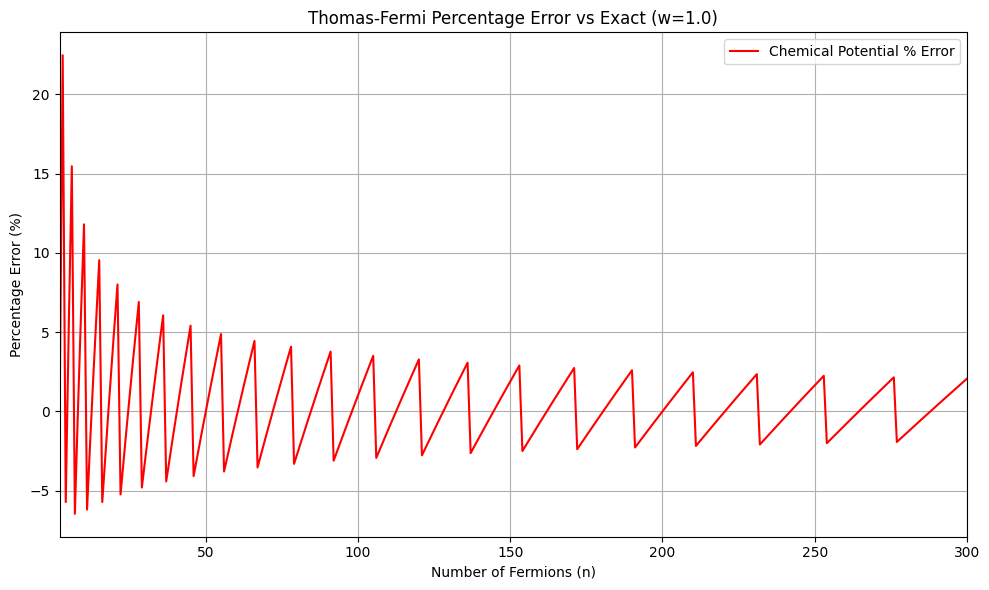

In [9]:
# --- Percentage Error Plot ---
# Plotting the percentage error: 100 * (TF - Exact) / Exact

plt.figure(figsize=(10, 6))
plt.xlim(2, ntop)

# For Chemical Potential (cp)
# mu_H_all_high starts at n=2, so it perfectly aligns with n_vals_TF starting at n=2
mu_exact_slice = mu_H_all_high[:len(n_vals_TF)]
cp_pct_error = 100 * (mu_TF - mu_exact_slice) / mu_exact_slice

plt.plot(n_vals_TF, cp_pct_error, label="Chemical Potential % Error", color="red")

# # For Heat Capacity (Cv) if needed
# # Cv_H_n_high starts at n=1, so we offset by 1 to start at n=2
# Cv_exact_slice = Cv_H_n_high[1:1+len(n_vals_TF)]
# cv_pct_error = 100 * (Cv_TF_n - Cv_exact_slice) / Cv_exact_slice

# plt.plot(n_vals_TF, cv_pct_error, label="Heat Capacity % Error", color="blue")

plt.xlabel("Number of Fermions (n)")
plt.ylabel("Percentage Error (%)")
plt.title(f"Thomas-Fermi Percentage Error vs Exact (w={w_val})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# Export the chemical potential plot data to CSV
df_sim = pd.DataFrame({
    'n': n_vals_mu,
    'mu_Thermo': mu_T_all,
    'mu_Ham': mu_H_all,
})
if has_high_beads:
    df_sim['mu_Ham_Exact'] = mu_H_all_high

df_tf = pd.DataFrame({
    'n_TF': n_vals_TF,
    'mu_TF': mu_TF
})

df_export = pd.concat([df_sim, df_tf], axis=1)
csv_filename = 'chemical_potential_plot_data.csv'
df_export.to_csv(csv_filename, index=False)
print(f"Data successfully exported to {csv_filename}")


Data successfully exported to chemical_potential_plot_data.csv
